Processed and saved ./output_images/result_0.png with loss: 0.6900
Processed and saved ./output_images/result_1.png with loss: 0.6881
Processed and saved ./output_images/result_2.png with loss: 0.6854
Processed and saved ./output_images/result_3.png with loss: 0.6865
Processed and saved ./output_images/result_4.png with loss: 0.6885
Processed and saved ./output_images/result_5.png with loss: 0.6855
Processed and saved ./output_images/result_6.png with loss: 0.6888
Processed and saved ./output_images/result_7.png with loss: 0.6918
Processed and saved ./output_images/result_8.png with loss: 0.6909
Processed and saved ./output_images/result_9.png with loss: 0.6853
Processed and saved ./output_images/result_10.png with loss: 0.6906
Processed and saved ./output_images/result_11.png with loss: 0.6861
Processed and saved ./output_images/result_12.png with loss: 0.6873
Processed and saved ./output_images/result_13.png with loss: 0.6846
Processed and saved ./output_images/result_14.png with los

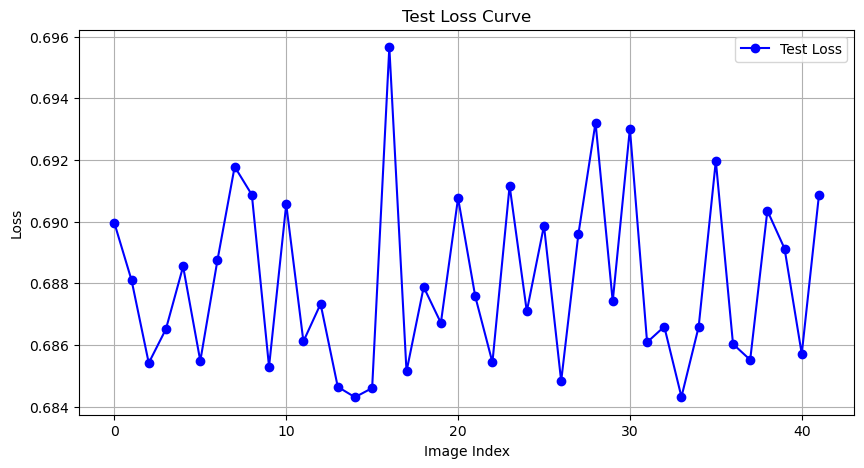

Loss curve saved to ./output_images/test_loss_curve.png


In [4]:
import glob
import numpy as np
import torch
from PIL import Image
from unet import UNet
import os
import matplotlib.pyplot as plt

# 初始化网络和设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = './models/model_best.pth'
if not os.path.exists(model_path):
    raise FileNotFoundError(f"The model checkpoint '{model_path}' does not exist.")
    
# 调整网络输出为单通道
net = UNet(n_channels=1, n_classes=1, bilinear=False)  # n_classes 设置为 1
net.to(device=device)
checkpoint = torch.load(model_path, map_location=device)
net.load_state_dict(checkpoint['net'])
net.eval()

# 加载测试数据
Test_Data_path = './test_image/'
Label_Data_path = './test_label/'
tests_path = glob.glob(Test_Data_path + '*.png')
if len(tests_path) == 0:
    print(f"No images found in {Test_Data_path}")
    exit(1)

output_dir = './output_images/'
os.makedirs(output_dir, exist_ok=True)

# 损失函数
criterion = torch.nn.BCELoss()
losses = []

for i, test_path in enumerate(tests_path):
    # 加载图片并归一化
    img = Image.open(test_path).convert('L')
    img = np.array(img, dtype=np.float32) / 255.0  # 归一化到 [0, 1]
    img = img.reshape(1, 1, img.shape[0], img.shape[1])  # 调整为 (1, 1, H, W)
    img_tensor = torch.from_numpy(img).to(device=device, dtype=torch.float32)
    
    # 加载实际标签
    label_name = os.path.basename(test_path)  # 获取文件名
    label_path = os.path.join(Label_Data_path, label_name)
    if not os.path.exists(label_path):
        print(f"Label file '{label_path}' not found. Skipping...")
        continue
    label = Image.open(label_path).convert('L')
    label = np.array(label, dtype=np.float32) / 255.0  # 归一化到 [0, 1]
    label = label.reshape(1, 1, label.shape[0], label.shape[1])  # 调整为 (1, 1, H, W)
    label_tensor = torch.from_numpy(label).to(device=device, dtype=torch.float32)
    
    # 预测
    with torch.no_grad():
        pred = net(img_tensor)  # 输出大小为 [1, 1, H, W]
        pred = torch.sigmoid(pred)  # 确保输出范围在 [0, 1]
    
    # 计算 Loss
    loss = criterion(pred, label_tensor)
    losses.append(loss.item())
    
    # 处理预测结果
    pred_np = pred.cpu().numpy()[0][0]
    pred_np = (pred_np >= 0.5).astype(np.uint8) * 255  # 二值化并转换为 255
    
    # 保存结果图像
    pred_img = Image.fromarray(pred_np.astype(np.uint8))
    save_res_path = os.path.join(output_dir, f"result_{i}.png")
    pred_img.save(save_res_path)
    print(f"Processed and saved {save_res_path} with loss: {loss.item():.4f}")

# 绘制 Loss 曲线
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Test Loss", marker='o', color='b')
plt.xlabel("Image Index")
plt.ylabel("Loss")
plt.title("Test Loss Curve")
plt.legend()
plt.grid()
loss_curve_path = os.path.join(output_dir, "test_loss_curve.png")
plt.savefig(loss_curve_path)
plt.show()
print(f"Loss curve saved to {loss_curve_path}")
